In [1]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
#!pip install statsmodels
#!pip install matplotlib
import statsmodels.api as sm

In [55]:
# Set the folder containing all your CSVs
#folder_path = 'residuals/residuals_tech'  # ← or your full path if not in current directory
folder_path = 'residuals/residuals_util'  # ← or your full path if not in current directory
#folder_path = 'residuals/residuals_hc'  # ← or your full path if not in current directory
#folder_path = 'residuals/residuals_energy'  # ← or your full path if not in current directory
#folder_path = 'residuals/residuals_re'  # ← or your full path if not in current directory
sort_column = 'Residual'     # ← replace with the name of the column to sort by (e.g., 'daily_return')

# Store all dataframes
all_dfs = []

# Process each file
for filepath in glob.glob(os.path.join(folder_path, '*.csv')):
    # Extract the fund name (e.g., PRUZX from PRUZX_1999_2024.csv)
    filename = os.path.basename(filepath)
    fund_name = filename.split('_')[0]  # gets PRUZX

    # Load data
    df = pd.read_csv(filepath)

    # Add a new column with the fund name
    df['Fund'] = fund_name
    df['Year'] = pd.to_datetime(df['Date']).dt.year
    # Append to list
    all_dfs.append(df)

# Merge all into one DataFrame
merged_df = pd.concat(all_dfs, ignore_index=True)

# Drop rows with NA in the sort column (if needed)
merged_df = merged_df.dropna(subset=[sort_column])

# Sort in ascending order by the sort column
merged_df = merged_df.sort_values(by=sort_column, ascending=True)

# Add quantile column: 1 = lowest, 4 = highest
merged_df['Quantile'] = pd.qcut(merged_df[sort_column], q=10, labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Save merged + sorted + quantiled DataFrame
merged_df.to_csv('quantiles_util.csv', index=False)

# Optional preview
print(merged_df[['Fund', sort_column, 'Quantile']].head())


        Fund  Residual Quantile
13812  EVUAX -0.099526        1
37743  PRUAX -0.097869        1
32294  ICTUX -0.080979        1
500    FKUTX -0.065813        1
61233  GASFX -0.060920        1


In [2]:
# Paths
fund_folder_tech = 'funds/tech'
fund_folder_hc = 'funds/healthcare'
fund_folder_e = 'funds/energy'
fund_folder_uti= 'funds/utilities'
fund_folder_re = 'funds/re'
spy_path = 'benchmarks/SPY_1999_2025.csv'
output_folder_tech = 'residuals/residuals_tech'
output_folder_uti = 'residuals/residuals_util'
output_folder_re = 'residuals/residuals_re'
output_folder_hc = 'residuals/residuals_hc'
output_folder_e = 'residuals/residuals_energy'
quantiles_tech = 'quantiles/quantiles_tech.csv'
quantiles_uti = 'quantiles/quantiles_util.csv'
quantiles_re = 'quantiles/quantiles_re.csv'
quantiles_hc = 'quantiles/quantiles_hc.csv'
quantiles_e = 'quantiles/quantiles_e.csv'

In [8]:
Quart = pd.read_csv(quantiles_tech)

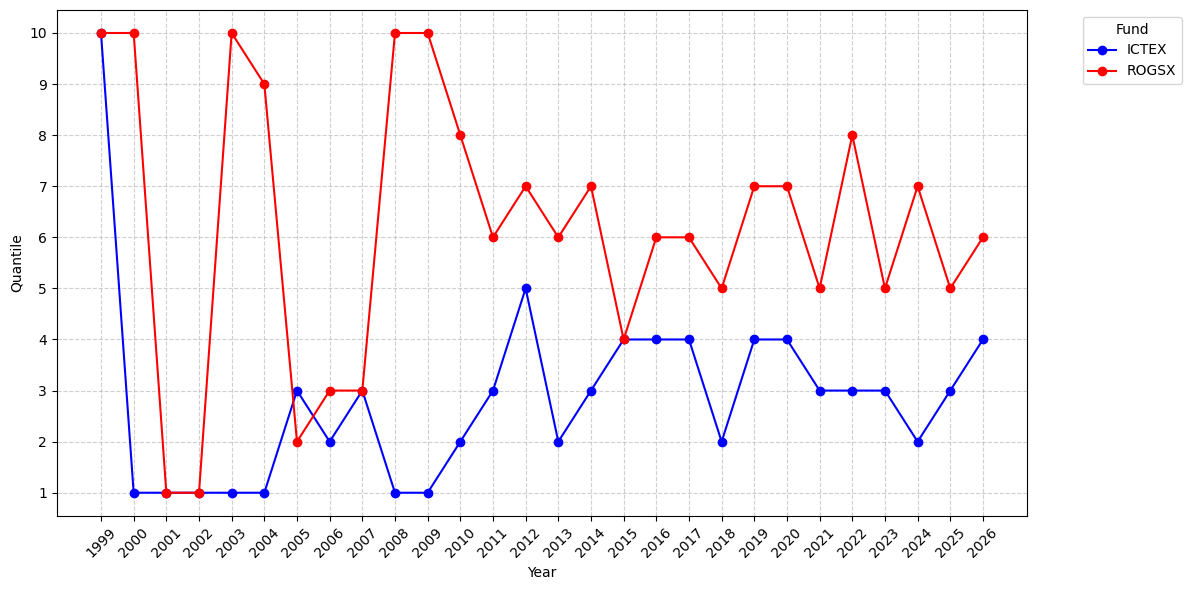

In [10]:
import random

# Majority quantile per fund-year
majority_quantile = (
    Quart.groupby(["Fund", "Year"])["Quantile"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

# Randomly select two funds
all_funds = majority_quantile["Fund"].unique()
selected_funds = random.sample(list(all_funds), 2)
majority_quantile = majority_quantile[majority_quantile["Fund"].isin(selected_funds)]

# Prepare full list of years for X-axis ticks
years = sorted(majority_quantile["Year"].unique())

# Define two colors for the two selected funds
colors = ['#0000FF', '#FF0000']
color_map = {fund: colors[i] for i, fund in enumerate(selected_funds)}

# Plot
plt.figure(figsize=(12, 6))
for fund, group in majority_quantile.groupby("Fund"):
    plt.plot(
        group["Year"],
        group["Quantile"],
        marker='o',
        linestyle='-',
        label=fund,
        color=color_map[fund]
    )

plt.xticks(years, rotation=45)
plt.yticks(range(1, 11))
plt.xlabel("Year")
plt.ylabel("Quantile")
plt.legend(title="Fund", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("plots/util_2funds.jpg", dpi=1200, bbox_inches="tight")
plt.show()

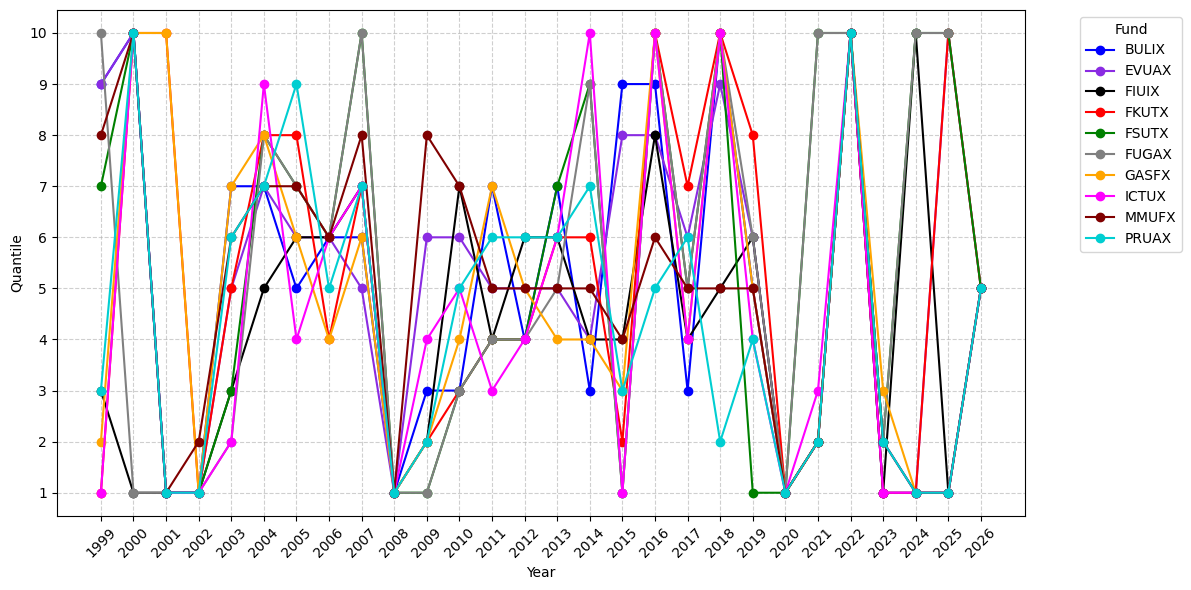

In [58]:
# Majority quantile per fund-year
majority_quantile = (
    Quart.groupby(["Fund", "Year"])["Quantile"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

# Prepare full list of years for X-axis ticks
years = sorted(majority_quantile["Year"].unique())

# Define colors for funds (13 distinct colors)
colors = [
    '#0000FF',  # Blue
    '#8A2BE2',  # Violet / BlueViolet
    '#000000',  # Black
    '#FF0000',  # Red
    '#008000',  # Green
    '#808080',  # Grey
    '#FFA500',  # Orange
    '#FF00FF',  # Magenta / Fuchsia
    '#800000',  # Maroon
    '#00CED1',  # Dark Turquoise
    '#00FF7F'   # Parrot Green / SpringGreen
]

# Map each fund to a color
funds = majority_quantile["Fund"].unique()
color_map = {fund: colors[i % len(colors)] for i, fund in enumerate(funds)}

# Plot
plt.figure(figsize=(12, 6))
for fund, group in majority_quantile.groupby("Fund"):
    plt.plot(
        group["Year"],
        group["Quantile"],
        marker='o',
        linestyle='-',
        label=fund,
        color=color_map[fund]
    )

plt.xticks(years, rotation=45)

plt.yticks(range(1, 11))
plt.xlabel("Year")
plt.ylabel("Quantile")
#plt.title("Majority Quantile per Fund-Year")
plt.legend(title="Fund", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
# Save as JPEG
plt.savefig("plots/util.jpg", dpi=1200, bbox_inches="tight")

plt.show()

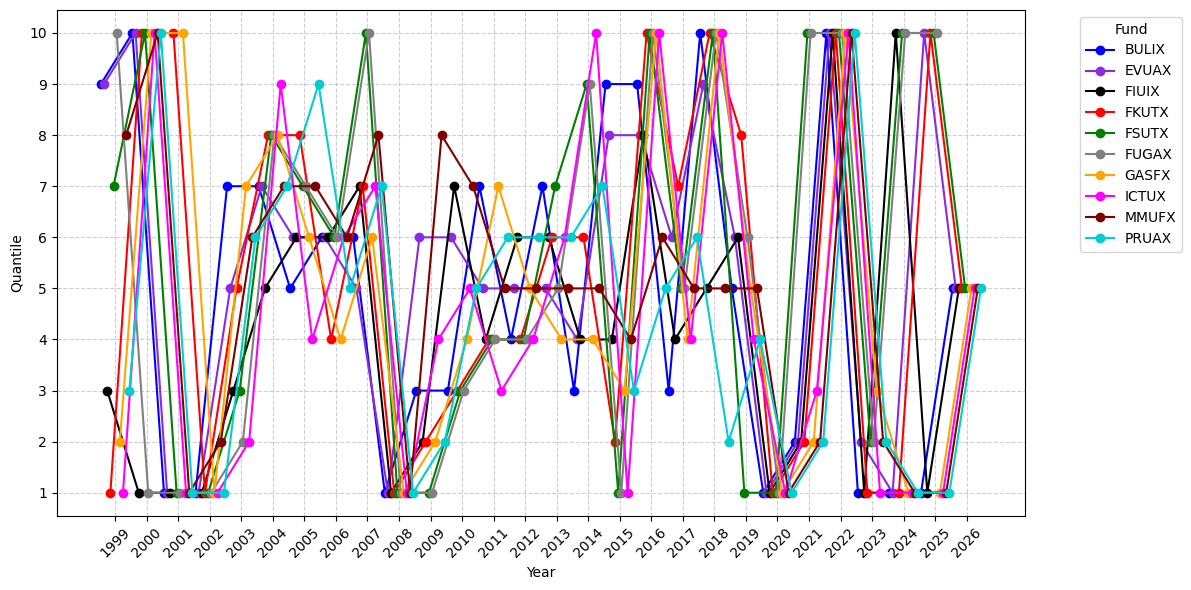

In [59]:
# Majority quantile per fund-year
majority_quantile = (
    Quart.groupby(["Fund", "Year"])["Quantile"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

# Prepare years and assign each fund a small X-offset
funds = majority_quantile["Fund"].unique()
offset_map = {fund: i * 0.1 - (len(funds) - 1) * 0.05 for i, fund in enumerate(funds)}

# Map each fund to a color
color_map = {fund: colors[i % len(colors)] for i, fund in enumerate(funds)}

plt.figure(figsize=(12, 6))

for fund, group in majority_quantile.groupby("Fund"):
    # Apply offset so lines don't overlap exactly
    x_vals = group["Year"] + offset_map[fund]
    plt.plot(
        x_vals,
        group["Quantile"],
        marker='o',
        linestyle='-',
        label=fund,
        color=color_map[fund]
    )

# Force ticks for all years, tilt labels
years = sorted(majority_quantile["Year"].unique())
plt.xticks(years, rotation=45)

plt.yticks(range(1, 11))
plt.xlabel("Year")
plt.ylabel("Quantile")
#plt.title("Majority Quantile per Fund-Year (With Jitter to Reduce Overlap)")
plt.legend(title="Fund", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("plots/util_read.jpg", dpi=1200, bbox_inches="tight")
plt.show()

In [60]:
df = pd.read_csv(quantiles_uti)
df['Quantile'] = pd.to_numeric(df['Quantile'], errors='coerce')

Overall Hamming distance (all funds): 0.599

Diversification impact (largest drop = most diversification):
       H_without_fund  drop_in_diversification
Fund                                          
EVUAX        0.590000                 0.008721
MMUFX        0.593000                 0.005721
PRUAX        0.595000                 0.003721
ICTUX        0.597000                 0.001721
FUGAX        0.597222                 0.001499
GASFX        0.599000                -0.000279
FIUIX        0.601000                -0.002279
BULIX        0.605000                -0.006279
FSUTX        0.605000                -0.006279
FKUTX        0.605000                -0.006279

Fund contributing the most diversification: EVUAX


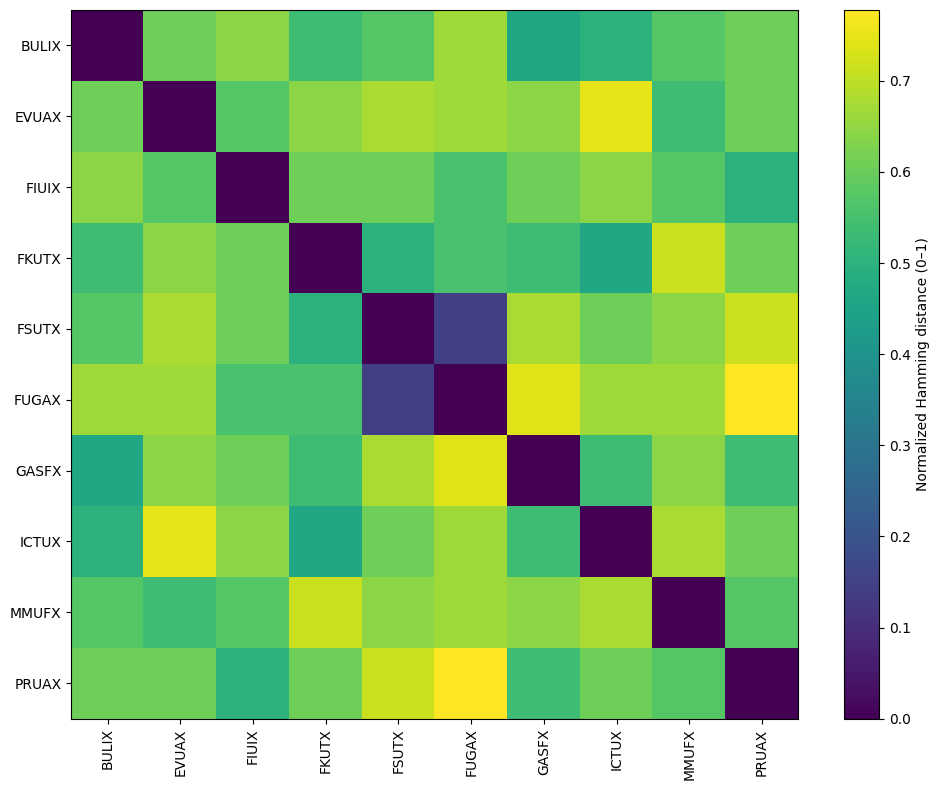

In [61]:
df['Quantile'] = pd.to_numeric(df['Quantile'], errors='coerce')

def mode_with_tiebreak(series):
    # mode() may return multiple values; pick the one whose value is closest to the median
    s = series.dropna().astype(float)
    if s.empty:
        return np.nan
    modes = s.mode()
    if len(modes) == 1:
        return int(modes.iloc[0])
    med = s.median()
    best = min(modes, key=lambda v: abs(v - med))
    return int(best)

yearly = (
    df.groupby(['Year', 'Fund'], as_index=False)['Quantile']
      .agg(yearly_label=mode_with_tiebreak)
)

trajectories = (
    yearly.pivot(index='Year', columns='Fund', values='yearly_label')
          .sort_index()
)
def hamming_distance(s1: pd.Series, s2: pd.Series, normalize=True):
    mask = s1.notna() & s2.notna()
    n = int(mask.sum())
    if n == 0:
        return np.nan, 0  # no overlap
    mismatches = int((s1[mask] != s2[mask]).sum())
    if normalize:
        return mismatches / n, n
    else:
        return mismatches, n

def avg_hamming_distance(trajs: pd.DataFrame, normalize=True):
    funds = list(trajs.columns)
    distances = []
    overlaps = []
    for f1, f2 in combinations(funds, 2):
        d, n = hamming_distance(trajs[f1], trajs[f2], normalize=normalize)
        if not np.isnan(d):
            distances.append(d)
            overlaps.append(n)
    if not distances:
        return np.nan
    return np.average(distances, weights=overlaps)

H_all = avg_hamming_distance(trajectories, normalize=True)
print(f"Overall Hamming distance (all funds): {H_all:.3f}")

impact = []
for fund in trajectories.columns:
    reduced = trajectories.drop(columns=fund)
    H_minus = avg_hamming_distance(reduced, normalize=True)
    impact.append({
        'Fund': fund,
        'H_without_fund': H_minus,
        'drop_in_diversification': H_all - H_minus
    })

impact_df = pd.DataFrame(impact).set_index('Fund').sort_values('drop_in_diversification', ascending=False)
print("\nDiversification impact (largest drop = most diversification):")
print(impact_df)

# Best fund to KEEP (removing it hurts diversification the most)
best = impact_df['drop_in_diversification'].idxmax()
print(f"\nFund contributing the most diversification: {best}")

funds = list(trajectories.columns)
M = pd.DataFrame(np.nan, index=funds, columns=funds)
Noverlap = pd.DataFrame(0, index=funds, columns=funds, dtype=int)

for f1, f2 in combinations(funds, 2):
    d, n = hamming_distance(trajectories[f1], trajectories[f2], normalize=True)
    M.loc[f1, f2] = M.loc[f2, f1] = d
    Noverlap.loc[f1, f2] = Noverlap.loc[f2, f1] = n

np.fill_diagonal(M.values, 0.0)

plt.figure(figsize=(10, 8))
im = plt.imshow(M.values, aspect='auto')
plt.xticks(range(len(funds)), funds, rotation=90)
plt.yticks(range(len(funds)), funds)
plt.colorbar(im, label='Normalized Hamming distance (0–1)')
#plt.title('Pairwise Hamming Distance (yearly labels)')
plt.tight_layout()
plt.savefig("plots/util_hamming.jpg", dpi=1200, bbox_inches="tight")
plt.show()

In [19]:
df = pd.read_csv(quantiles_re)
# Pivot the data: count of funds per quantile per year
quantile_counts = df.groupby(['Year', 'Quantile']).size().unstack(fill_value=0)
# Plot vertical stacked bar chart
quantile_counts

Quantile,1,2,3,4,5,6,7,8,9,10
Year,,,,,,,,,,
1999,394,430,298,298,180,167,184,214,240,345
2000,390,301,187,159,173,189,197,241,384,529
2001,288,269,261,249,261,186,257,293,302,373
2002,348,269,225,185,199,228,225,244,338,500
2003,137,232,340,339,293,362,304,241,277,225
2004,207,251,195,247,251,299,352,319,349,280
2005,110,252,301,277,293,339,356,411,300,111
2006,113,247,287,358,352,291,252,373,349,128
2007,380,372,344,231,231,200,181,212,289,310


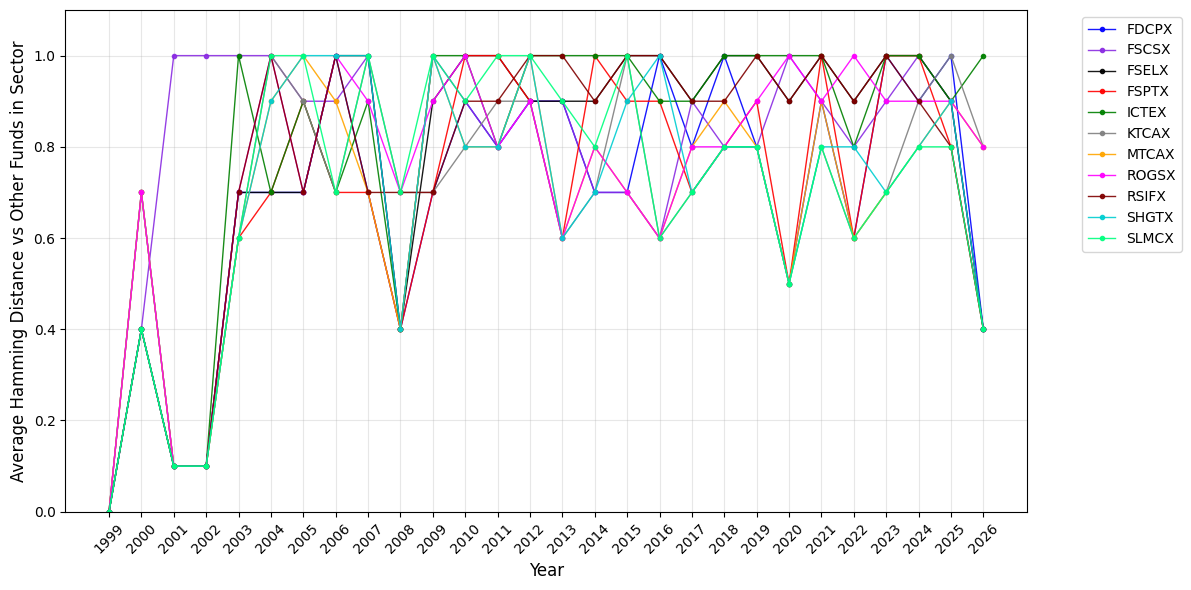

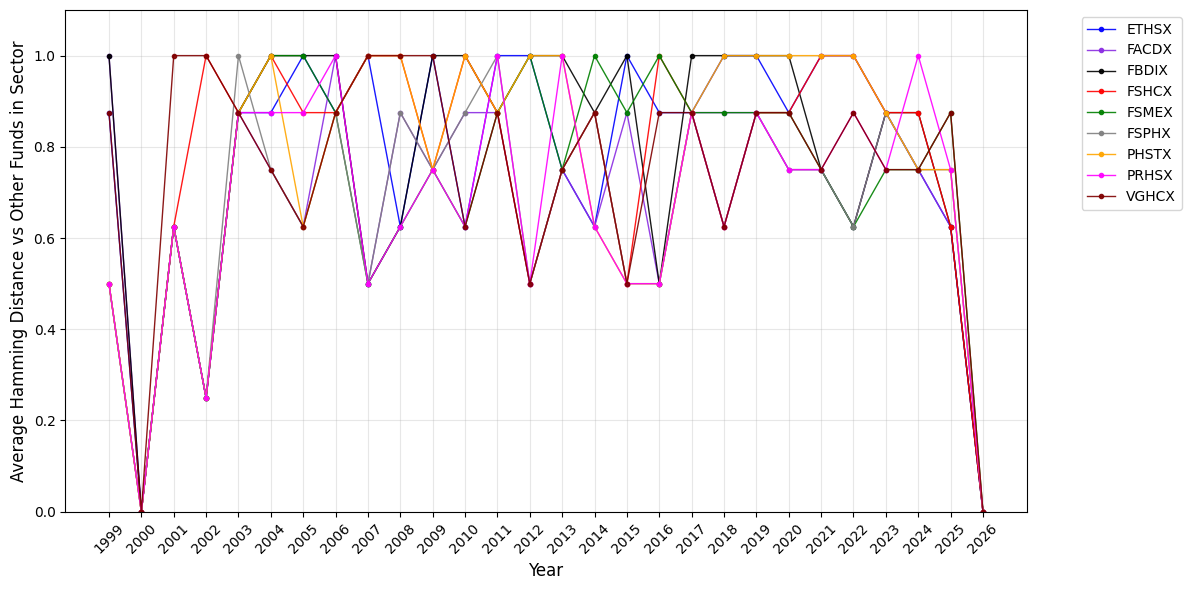

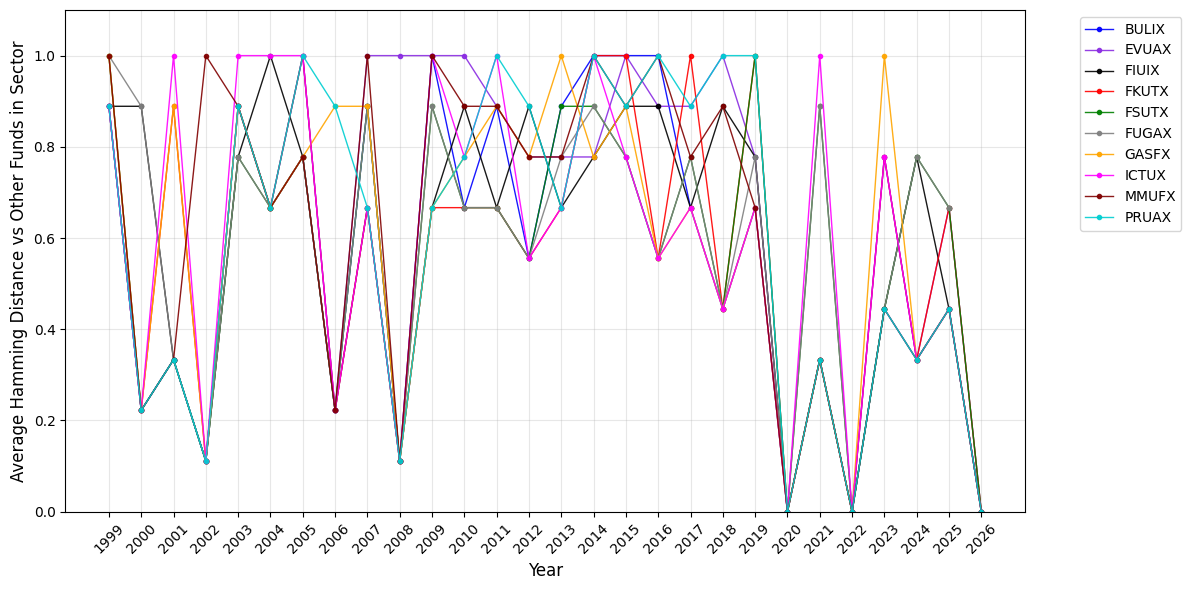

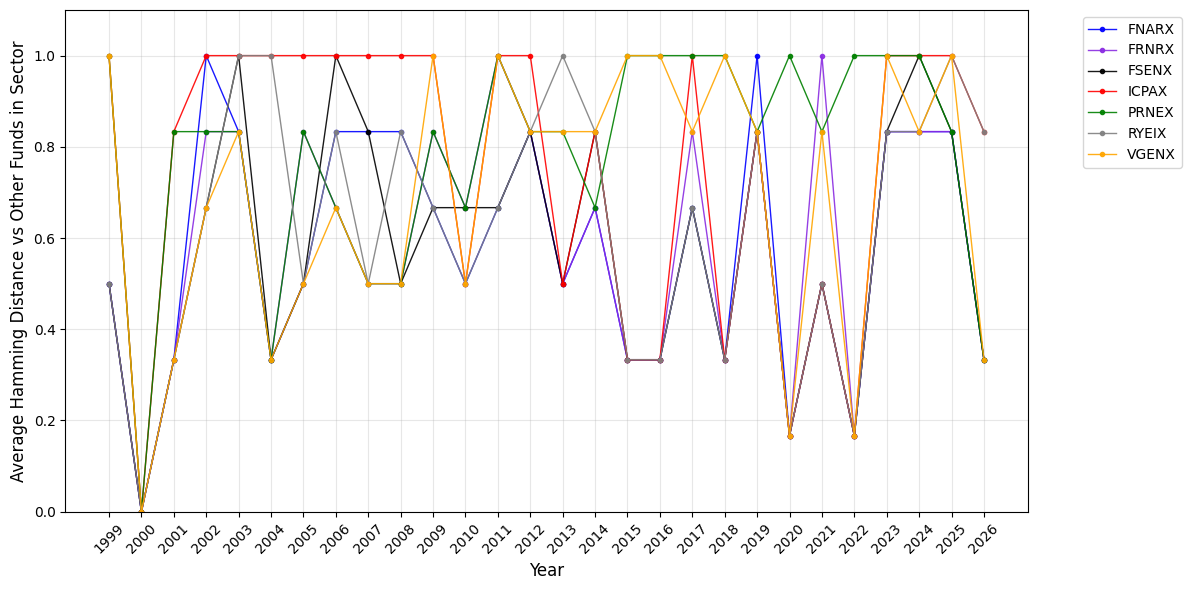

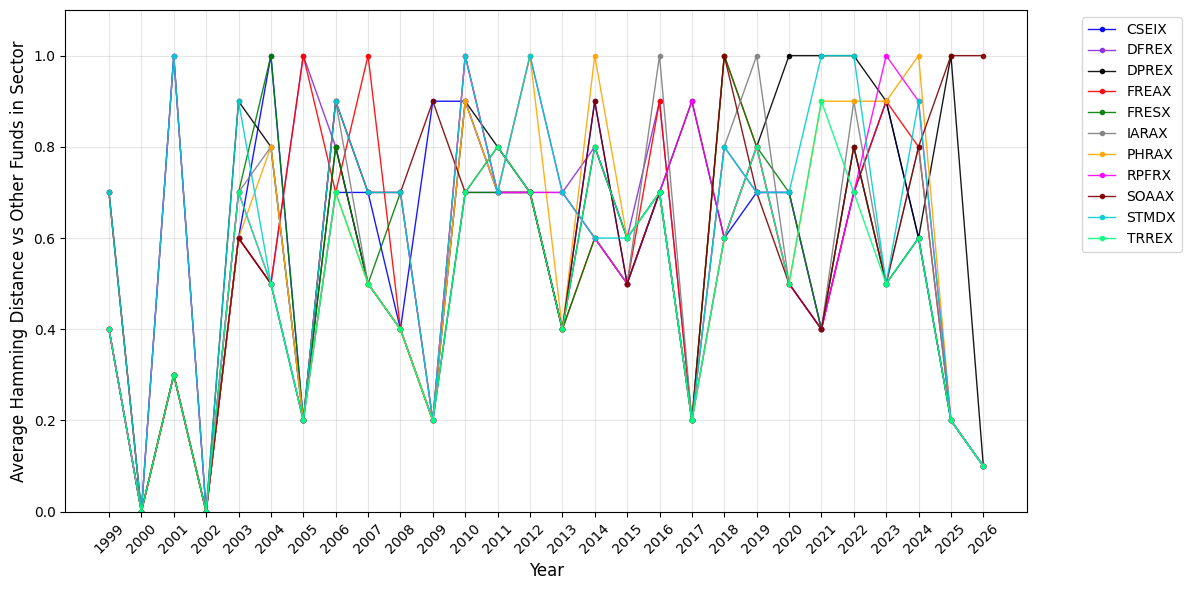

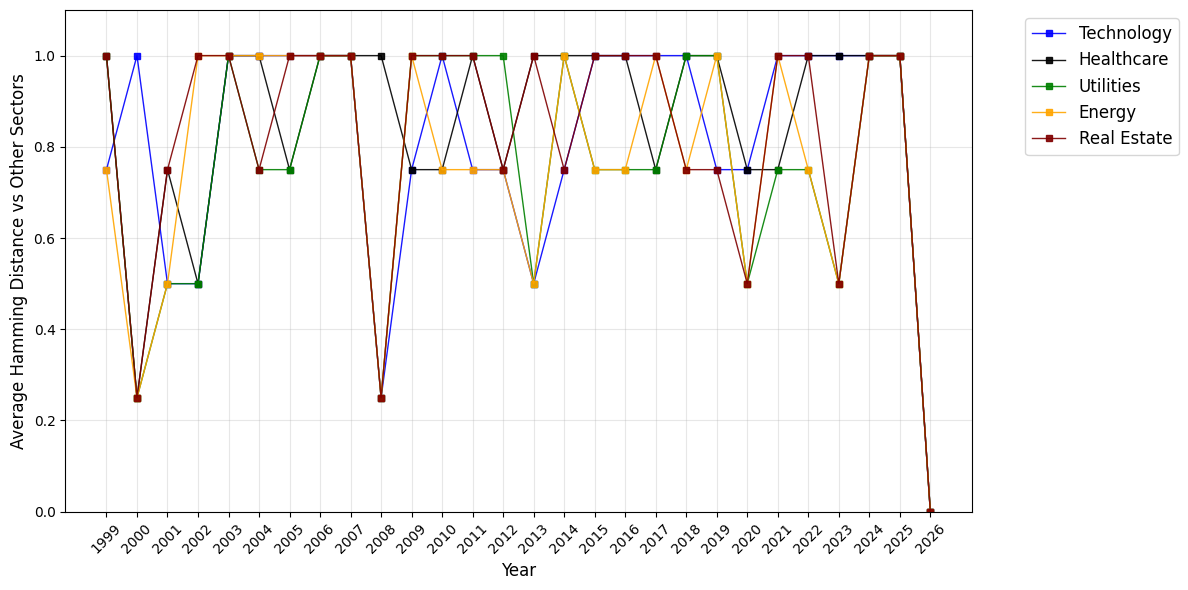

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Define your sector files
sector_files = {
    'Technology': quantiles_tech,      
    'Healthcare': quantiles_hc, 
    'Utilities': quantiles_uti,       
    'Energy': quantiles_e,         
    'Real Estate': quantiles_re      
}

# Load and combine all sector files
dfs = []
sector_data = {}  # Store individual sector dataframes
for sector_name, filename in sector_files.items():
    try:
        # If it's a filename string, read the CSV
        if isinstance(filename, str):
            sector_df = pd.read_csv(filename)
        else:
            # If it's already a DataFrame, copy it
            sector_df = filename.copy()
        
        sector_df['Sector'] = sector_name  # Add sector column
        sector_data[sector_name] = sector_df  # Store individual sector data
        dfs.append(sector_df)
    except Exception as e:
        print(f"Error loading {sector_name}: {e}")

# Combine all dataframes for overall analysis
df = pd.concat(dfs, ignore_index=True)

# Colors for sectors in the final plot
sector_colors = ['#0000FF', '#000000', '#008000', '#FFA500', '#800000'] 

def mode_with_tiebreak(series):
    s = series.dropna().astype(float)
    if s.empty:
        return np.nan
    modes = s.mode()
    if len(modes) == 1:
        return int(modes.iloc[0])
    med = s.median()
    best = min(modes, key=lambda v: abs(v - med))
    return int(best)

def calculate_fund_hamming_distance(fund_data, all_other_funds_data):
    """Calculate average Hamming distance between one fund and all others for a given year"""
    distances = []
    
    for other_fund, other_quantile in all_other_funds_data.items():
        if pd.notna(fund_data) and pd.notna(other_quantile):
            distance = 0 if fund_data == other_quantile else 1
            distances.append(distance)
    
    return np.mean(distances) if distances else np.nan

# Convert Quantile to numeric for all data
df['Quantile'] = pd.to_numeric(df['Quantile'], errors='coerce')

sector_names = list(sector_data.keys())

for i, (sector_name, sector_df) in enumerate(sector_data.items()):
    # Create individual plot for this sector
    plt.figure(figsize=(12, 6))
    
    # Convert quantile to numeric for this sector
    sector_df['Quantile'] = pd.to_numeric(sector_df['Quantile'], errors='coerce')
    
    # Get yearly labels for each fund in this sector
    sector_yearly = (
        sector_df.groupby(['Year', 'Fund'], as_index=False)['Quantile']
                 .agg(yearly_label=mode_with_tiebreak)
    )
    
    # Create trajectories for this sector
    sector_trajectories = (
        sector_yearly.pivot(index='Year', columns='Fund', values='yearly_label')
                     .sort_index()
    )
    
    years = sector_trajectories.index
    sector_funds = sector_trajectories.columns
    
    # Plot each fund in this sector
    for j, fund in enumerate(sector_funds):
        fund_hamming_distances = []
        
        for year in years:
            # Get this fund's quantile for this year
            fund_quantile = sector_trajectories.loc[year, fund]
            
            # Get all other funds' quantiles in this sector for this year
            other_funds = {f: sector_trajectories.loc[year, f] for f in sector_funds if f != fund}
            
            # Calculate average hamming distance to all other funds in this sector
            hamming_dist = calculate_fund_hamming_distance(fund_quantile, other_funds)
            fund_hamming_distances.append(hamming_dist)
        
        # Use colors cyclically if more than 13 funds
        color_idx = j % len(colors)
        
        # Plot this fund's line
        plt.plot(years, fund_hamming_distances, marker='o', linewidth=1, 
                markersize=3, color=colors[color_idx], label=fund, alpha=0.9)
    
    #plt.title(f'{sector_name} Sector - Fund Diversification Analysis\n' f'({len(sector_funds)} funds within sector)', fontweight='bold', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Hamming Distance vs Other Funds in Sector', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.xticks(years, rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.savefig(f"plots/AHD_{sector_name}.jpg", dpi=1200, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(12, 6))

# Get yearly labels for overall analysis
yearly = (
    df.groupby(['Year', 'Fund', 'Sector'], as_index=False)['Quantile']
      .agg(yearly_label=mode_with_tiebreak)
)

# Calculate sector-level yearly labels (mode of funds in each sector)
sector_yearly_overall = []
for year in sorted(df['Year'].unique()):
    year_data = yearly[yearly['Year'] == year]
    for sector in sector_names:
        sector_year_data = year_data[year_data['Sector'] == sector]
        if not sector_year_data.empty:
            sector_label = mode_with_tiebreak(sector_year_data['yearly_label'])
            sector_yearly_overall.append({
                'Year': year,
                'Sector': sector,
                'yearly_label': sector_label
            })

sector_yearly_df = pd.DataFrame(sector_yearly_overall)

# Create sector trajectories
sector_trajectories_overall = (
    sector_yearly_df.pivot(index='Year', columns='Sector', values='yearly_label')
                    .sort_index()
)

years = sector_trajectories_overall.index

# Plot each sector line
for i, sector in enumerate(sector_names):
    sector_hamming_distances = []
    
    for year in years:
        # Get this sector's quantile for this year
        sector_quantile = sector_trajectories_overall.loc[year, sector]
        
        # Get all other sectors' quantiles for this year
        other_sectors = {s: sector_trajectories_overall.loc[year, s] 
                        for s in sector_names if s != sector}
        
        # Calculate average hamming distance to all other sectors
        hamming_dist = calculate_fund_hamming_distance(sector_quantile, other_sectors)
        sector_hamming_distances.append(hamming_dist)
    
    # Plot this sector's line
    plt.plot(years, sector_hamming_distances, marker='s', linewidth=1, 
            markersize=4, color=sector_colors[i], label=sector, alpha=0.9)

#plt.title('Inter-Sector Diversification Analysis\n' '(How Different Each Sector is from Others)', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Hamming Distance vs Other Sectors', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.xticks(years, rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig("plots/AHD_intersector.jpg", dpi=1200, bbox_inches="tight")
plt.show()
